# Setting Up and Running VPLanet Models

This tutorial walks through the full workflow for running a VPLanet stellar evolution simulation:

1. **Understanding VPLanet input files** — the primary control file (`vpl.in`) and body files (`star.in`)
2. **Running VPLanet from the command line** — a minimal working example using the `stellar` module
3. **Reading VPLanet output files** — the log file and time-series forward file
4. **Running the same model through `vplanet_inference`** — a Python interface with unit-aware parameter substitution

The example models a low-mass star (0.09 M☉, similar in mass to TRAPPIST-1) and tracks how its
luminosity, XUV luminosity, radius, effective temperature, and rotation period evolve over 8 Gyr.

---

**References:**
- [VPLanet documentation](https://virtualplanetarylaboratory.github.io/vplanet/)
- [VPLanet GitHub repository](https://github.com/VirtualPlanetaryLaboratory/vplanet)
- [vplanet_inference GitHub repository](https://github.com/jbirky/vplanet_inference)

In [1]:
import os
import subprocess
import numpy as np
import matplotlib.pyplot as plt
import vplanet_inference as vpi
import astropy.units as u

# vpi.INFILE_DIR points to the bundled template infile directory
INFILE_PATH = os.path.join(vpi.INFILE_DIR, "stellar/")
print(f"Infile directory: {INFILE_PATH}")

Infile directory: /home/jbirky/Tresorit/packages/vplanet_inference/infiles/stellar/


## 1. VPLanet Input Files: The Manual Way

A VPLanet simulation requires at minimum two types of input files:

| File | Purpose |
|------|---------|
| **`vpl.in`** | Primary control file — system-level settings (units, timing, bodies, output) |
| **`<body>.in`** | One file per body — physics modules, initial conditions, and body-level parameters |

VPLanet uses a consistent **option naming convention** based on the leading character(s) of each option name:

| Prefix | Data type | Example |
|--------|-----------|--------|
| `b` | Boolean (0 or 1) | `bDoForward 1` |
| `i` | Integer | `iVerbose 0` |
| `d` | Double (float) | `dMass 0.09` |
| `s` | String | `sStellarModel baraffe` |
| `sa` | String array (multiple values) | `saBodyFiles star.in planet.in` |

Everything after a `#` on a line is a comment and is ignored by the parser.
Option names are case-sensitive and must be spelled exactly as documented.

See the [VPLanet input options reference](https://virtualplanetarylaboratory.github.io/vplanet/options.html)
for a complete listing of all available parameters.

### 1.1 The Primary Input File (`vpl.in`)

The primary file sets system-wide options and lists the body files to load.
It must always be named **`vpl.in`** and be present in the simulation directory.

In [2]:
with open(os.path.join(INFILE_PATH, "vpl.in")) as f:
    print(f.read())

# Primary input file for Trappist system
sSystemName	Trappist			# System Name
iVerbose	0			# Verbosity level
bOverwrite	1			# Allow file overwrites?

# All space after a # is ignored, as is white space
# The first lowercase letter(s) denote the cast: b=boolean, i=int, d=double,
# s=string. An "a" indicates an array and multiple arguments are allowed/expected.

# List of "body files" that contain body-specific parameters
saBodyFiles	star.in	# The host star

# Array options can continue to the next line with a terminating "$". The $ can be
# at the end of the string or not. Comments are allowed afterwards.

# Input/Output Units
sUnitMass	solar		# Options: gram, kg, Earth, Neptune, Jupiter, solar
sUnitLength	aU		# Options: cm, m, km, Earth, Jupiter, solar, AU
sUnitTime	YEAR		# Options: sec, day, year, Myr, Gyr
sUnitAngle	d		# Options: deg, rad
sUnitTemp       K

# Units specified in the primary input file are propagated into the bodies. Otherwise
# specifiy units on a per body basis in th

**Key options explained:**

| Option | Value | Description |
|--------|-------|-------------|
| `sSystemName` | `Trappist` | Prefix for all output files (e.g. `Trappist.log`, `Trappist.star.forward`) |
| `iVerbose` | `0` | Verbosity level printed to terminal (0 = silent, 5 = maximum) |
| `bOverwrite` | `1` | Allow output files to be overwritten on re-runs |
| `saBodyFiles` | `star.in` | Space-separated list of body input files to load |
| `sUnitMass` | `solar` | Mass unit for input/output (`gram`, `kg`, `Earth`, `Neptune`, `Jupiter`, `solar`) |
| `sUnitLength` | `AU` | Length unit (`cm`, `m`, `km`, `Earth`, `Jupiter`, `solar`, `AU`) |
| `sUnitTime` | `YEAR` | Time unit (`sec`, `day`, `year`, `Myr`, `Gyr`) |
| `sUnitAngle` | `d` | Angle unit (`d` = degrees, `rad` = radians) |
| `bDoLog` | `1` | Write a `.log` file summarising initial and final state |
| `bDoForward` | `1` | Run the simulation forward in time |
| `bVarDt` | `1` | Use adaptive (variable) timestepping |
| `dEta` | `1e-2` | Coefficient controlling adaptive timestep size (smaller = more accurate, slower) |
| `dStopTime` | `8e9` | Simulation end time in `sUnitTime` units (here: 8 Gyr) |
| `dOutputTime` | `1e7` | Interval at which time-series data are written (here: every 10 Myr) |

> **VPLanet docs:** [Primary input file options](https://virtualplanetarylaboratory.github.io/vplanet/options.html#primary-input-file)

### 1.2 Body Files (`star.in`)

Each body in the simulation — star, planet, or moon — has its own `.in` file.
The **`saModules`** option activates the VPLanet physics modules for that body;
each module introduces additional parameters specific to that physics.

Here we use the `stellar` module, which models stellar evolution
using the [Baraffe et al. (2015)](https://doi.org/10.1051/0004-6361/201425481) pre-main-sequence grids
and the [Matt et al. (2015)](https://doi.org/10.1088/2041-8205/799/2/L23) magnetic braking prescription.

See the [VPLanet modules reference](https://virtualplanetarylaboratory.github.io/vplanet/modules.html)
for the full list of available modules and their options.

In [3]:
with open(os.path.join(INFILE_PATH, "star.in")) as f:
    print(f.read())

# Host star parameters
sName		star                  # Body name
saModules    	stellar               # Active modules

# Physical properties
dMass        	0.09                  # Mass in Msun
dRotPeriod      -1.0                  # Rotation period, negative -> days
dAge            1.0e6                 # Initial age [yr]

# STELLAR parameters
sStellarModel	  baraffe             # Stellar evolution model
bHaltEndBaraffeGrid 0                 # Don't end sim when we reach end of grid
sMagBrakingModel  matt                # Magnetic braking model
dSatXUVFrac       1.0e-3              # XUV Saturation fraction
dSatXUVTime       -1.0                # XUV Saturation timescale, negative-> in Gyr
dXUVBeta          1.23                # XUV decay power law exponent

saOutputOrder 	Time -Luminosity -LXUVStellar -Radius Temperature -RotPer # Outputs



**Key options explained:**

| Option | Value | Description |
|--------|-------|-------------|
| `sName` | `star` | Name of this body; must match the filename without `.in`. Used to label output files |
| `saModules` | `stellar` | Physics modules active for this body |
| `dMass` | `0.09` | Stellar mass in `sUnitMass` units (here: 0.09 M☉) |
| `dRotPeriod` | `-1.0` | Initial rotation period. **Negative value** → units are days regardless of `sUnitTime` |
| `dAge` | `1e6` | Starting age in `sUnitTime` (here: 1 Myr — the simulation starts at this age) |
| `sStellarModel` | `baraffe` | Stellar evolution grid (`baraffe`, `solar`, `proxima`, `none`) |
| `sMagBrakingModel` | `matt` | Magnetic braking prescription (`matt`, `reiners`, `skumanich`, `none`) |
| `dSatXUVFrac` | `1e-3` | XUV saturation luminosity as a fraction of bolometric luminosity |
| `dSatXUVTime` | `-1.0` | XUV saturation timescale. **Negative value** → units are Gyr |
| `dXUVBeta` | `1.23` | Power-law exponent for XUV decay after saturation |
| `saOutputOrder` | `Time -Luminosity ...` | Variables written to the time-series `.forward` file |

#### The `saOutputOrder` option

This controls what columns appear in the `.forward` output file.
A **negative sign prefix** (`-Luminosity`) instructs VPLanet to output that quantity in custom units
rather than the system-wide units set in `vpl.in`:

```
saOutputOrder   Time -Luminosity -LXUVStellar -Radius Temperature -RotPer
```

The actual units used for each column are reported in the log file's `Output Order:` line.

To check what the custom units are for a vplanet output, run the following line in the command line:

```bash
vplanet -h
```

## 2. Running VPLanet from the Command Line

Once `vpl.in` and the body files are in place, run the simulation by navigating to the infile directory
and calling:

```bash
cd /path/to/infiles/stellar/
vplanet vpl.in
```

The argument `vpl.in` is required — it tells VPLanet which primary input file to use.
From this notebook, we can do the same thing with `subprocess`:

In [4]:
result = subprocess.run(
    ["vplanet", "vpl.in"],
    cwd=INFILE_PATH,
    capture_output=True,
    text=True,
)

if result.returncode == 0:
    print("VPLanet finished successfully.")
    print(result.stdout if result.stdout else "(no terminal output — iVerbose is set to 0)")
else:
    print("VPLanet encountered an error:")
    print(result.stderr)

VPLanet finished successfully.
(no terminal output — iVerbose is set to 0)


With `iVerbose 0`, VPLanet produces no terminal output on a successful run.
Setting `iVerbose 5` in `vpl.in` will print detailed progress messages.

All simulation output is written to files — described in the next section.

## 3. Understanding VPLanet Output Files

After a successful run, VPLanet creates the following output files in the simulation directory.
The filenames are prefixed with `sSystemName` (here: `Trappist`):

| File | Description |
|------|-------------|
| `Trappist.log` | Human-readable log with the initial and final state of every quantity, in SI units |
| `Trappist.star.forward` | Time-series data for the `star` body (columns defined by `saOutputOrder`) |

If you had multiple bodies (e.g. a planet named `planet`),
there would be a separate `Trappist.planet.forward` file for each one.

### 3.1 The Log File

The log file (`Trappist.log`) is written in SI units regardless of the `sUnitMass`/`sUnitLength`/`sUnitTime`
settings in `vpl.in`. It is divided into four sections:

1. **Header** — executable path, VPLanet version, input files used, and internal unit system
2. **Formatting** — integration method, timestep information
3. **Initial system properties** — complete state of every body at `t = dAge`
4. **Final system properties** — complete state of every body at `t = dAge + dStopTime`

The log file is the most reliable place to read initial and final values for any quantity,
including quantities not listed in `saOutputOrder`. The `Output Order:` line near the end
of each body's section also confirms the column order and units of the `.forward` file.

In [5]:
log_path = os.path.join(INFILE_PATH, "Trappist.log")
with open(log_path) as f:
    print(f.read())

-------- Log file Trappist.log -------

Executable: /home/jbirky/anaconda3/envs/vpi/bin/vplanet
Version: Unknown
System Name: Trappist
Primary Input File: vpl.in
Body File #1: star.in
Allow files to be overwitten: Yes
Mass Units: Grams
Length Units: Meters
Time Units: Seconds
Angle Units: Radians

------- FORMATTING -----
Verbosity Level: 0
Crossover Decade for Scientific Notation: 4
Number of Digits After Decimal: 6
Integration Method: Runge-Kutta4
Direction: Forward
Time Step: 3.155760e+07
Stop Time: 2.524608e+17
Output Interval: 3.155760e+14
Use Variable Timestep: Yes
dEta: 0.010000
Minimum Value of ecc and obl: 1.000000e-10


---- INITIAL SYSTEM PROPERTIES ----
(Age) System Age [sec]: 3.155760e+13 
(Time) Simulation Time [sec]: 0.000000 
(TotAngMom) Total Angular Momentum [kg*m^2/sec]: 1.149304e+42 
(TotEnergy) Total System Energy [kg*m^2/sec^2]: -1.877809e+39 
(PotEnergy) Body's non-orbital Potential Energy [kg*m^2/sec^2]: -1.919599e+39 
(KinEnergy) Body's non-orbital Kinetic Ener

### 3.2 The Forward File

The forward file (`Trappist.star.forward`) contains one row per output timestep (`dOutputTime`),
with columns corresponding to the variables in `saOutputOrder`.

For this example:
```
saOutputOrder   Time -Luminosity -LXUVStellar -Radius Temperature -RotPer
```

The actual units for each column are confirmed in the log file:
```
Output Order: Time[year] Luminosity[LSUN] LXUVStellar[LSUN] Radius[Rearth] Temperature[K] RotPer[days]
```

The file is plain whitespace-delimited ASCII — easy to read with `numpy.loadtxt`.

In [6]:
forward_path = os.path.join(INFILE_PATH, "Trappist.star.forward")
data = np.loadtxt(forward_path)

# Assign columns based on the Output Order line from the log file
time_yr     = data[:, 0]   # Time [yr]
luminosity  = data[:, 1]   # Luminosity [L_sun]
lxuv        = data[:, 2]   # XUV Luminosity [L_sun]
radius      = data[:, 3]   # Radius [R_earth]
temperature = data[:, 4]   # Effective temperature [K]
rot_period  = data[:, 5]   # Rotation period [days]

print(f"Timesteps recorded : {len(time_yr)}")
print(f"Time range         : {time_yr[0]:.2e} – {time_yr[-1]:.2e} yr")
print(f"Luminosity         : {luminosity[0]:.4f} → {luminosity[-1]:.6f} L_sun")
print(f"Radius             : {radius[0]:.2f}  → {radius[-1]:.2f}  R_earth")
print(f"Rotation period    : {rot_period[0]:.2f}  → {rot_period[-1]:.2f}  days")

Timesteps recorded : 801
Time range         : 0.00e+00 – 8.00e+09 yr
Luminosity         : 0.0592 → 0.000558 L_sun
Radius             : 104.75  → 12.33  R_earth
Rotation period    : 1.00  → 40.45  days


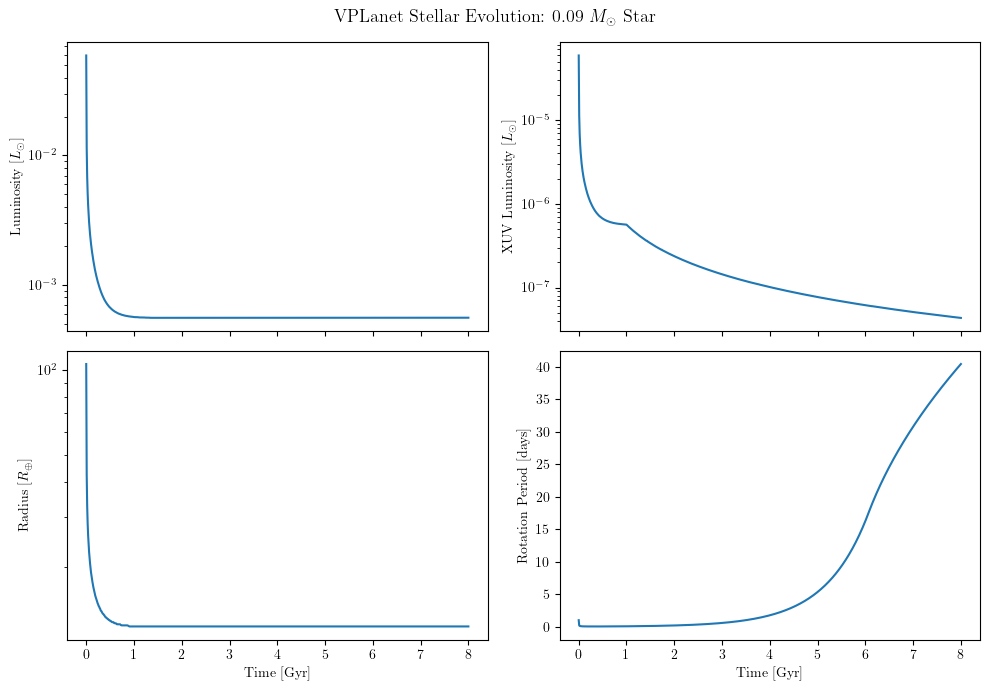

In [7]:
time_gyr = time_yr / 1e9

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

axes[0, 0].semilogy(time_gyr, luminosity)
axes[0, 0].set_ylabel(r"Luminosity [$L_\odot$]")

axes[0, 1].semilogy(time_gyr, lxuv)
axes[0, 1].set_ylabel(r"XUV Luminosity [$L_\odot$]")

axes[1, 0].semilogy(time_gyr, radius)
axes[1, 0].set_ylabel(r"Radius [$R_\oplus$]")

axes[1, 1].plot(time_gyr, rot_period)
axes[1, 1].set_ylabel("Rotation Period [days]")

for ax in axes[1]:
    ax.set_xlabel("Time [Gyr]")

fig.suptitle(r"VPLanet Stellar Evolution: 0.09 $M_\odot$ Star", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Running the Same Model Through `vplanet_inference`

`vplanet_inference` wraps VPLanet in a Python interface that handles:

- **Unit conversion** — specify parameters in convenient astronomical units via `astropy.units`;
  `vplanet_inference` automatically converts everything to SI before substituting into the infiles. \
  This means you don't have to worry about performing any unit conversions manually or setting the `vpl` 
  file units to be consistent with your input values--you just have to specify your value with astropy units!
- **Parameter substitution** — values are injected into template infiles at runtime;
  the template files are never modified
- **Output extraction** — final-state scalar values or time-series arrays are returned
  as NumPy arrays in the units you request

The central class is `VplanetModel`. You configure it once — specifying which parameters
to vary and which outputs to collect — then call `run_model(theta)` with a parameter vector.

### 4.1 Declaring Input Parameters (`inparams`)

`inparams` is a dict that maps parameter names to `astropy` units:

```python
inparams = {
    "<body_name>.<OptionName>": <astropy unit>,
    ...
}
```

- Use **`"vpl.<OptionName>"`** for parameters in `vpl.in`
- Use **`"<body_name>.<OptionName>"`** for parameters in a body file, where `<body_name>` matches
  the filename without `.in` (e.g. `"star.dMass"` for `star.in`)
- The `<OptionName>` must match the VPLanet option name exactly (e.g. `dMass`, `dStopTime`)

When you call `run_model(theta)`, the values in `theta` are interpreted in the declared units
and converted to SI before being written to the infiles.

### 4.2 Declaring Output Parameters (`outparams`)

`outparams` is a dict that maps output quantity names to the `astropy` units you want back:

```python
outparams = {
    "final.<body_name>.<Quantity>": <astropy unit>,
    # or
    "initial.<body_name>.<Quantity>": <astropy unit>,
    ...
}
```

- `<Quantity>` names match VPLanet output variable names — the same names used in `saOutputOrder`
  and listed in the [output variables reference](https://virtualplanetarylaboratory.github.io/vplanet/output.html)
- `final.*` reads from the **Final System Properties** section of the log file
- `initial.*` reads from the **Initial System Properties** section

**Note:** `VplanetModel` sorts `outparams` alphabetically internally.
The output array from `run_model()` follows this same sorted order, accessible via `vpm.outparams`.

In [8]:
# Input parameters: which options to vary and what units the values are supplied in
inparams = {
    "star.dMass":    u.Msun,   # stellar mass [solar masses]
    "vpl.dStopTime": u.Gyr,   # simulation stop time [Gyr]
}

# Output parameters: which final-state quantities to collect and what units to return them in
outparams = {
    "final.star.Luminosity":  u.Lsun,   # final bolometric luminosity [L_sun]
    "final.star.Radius":      u.Rsun,   # final stellar radius [R_sun]
    "final.star.Temperature": u.K,      # final effective temperature [K]
    "final.star.RotPer":      u.day,    # final rotation period [days]
}

We can check if our units are consistent with what `vplanet` expects by running:

In [9]:
vpi.check_units(inparams)


Parameter      User unit             VPLanet unit          Status
-----------------------------------------------------------------------------
star.dMass     solMass               earthMass             OK
vpl.dStopTime  Gyr                   yr                    OK



{'consistent': [('star.dMass', Unit("solMass"), Unit("earthMass")),
  ('vpl.dStopTime', Unit("Gyr"), Unit("yr"))],
 'inconsistent': [],
 'unknown': []}

In [10]:
vpi.check_units(outparams)


Parameter               User unit             VPLanet unit          Status
--------------------------------------------------------------------------------------
final.star.Luminosity   solLum                solLum                OK
final.star.Radius       solRad                earthRad              OK
final.star.RotPer       d                     d                     OK
final.star.Temperature  K                     (not in vplanet -H)   unknown



{'consistent': [('final.star.Luminosity', Unit("solLum"), Unit("solLum")),
  ('final.star.Radius', Unit("solRad"), Unit("earthRad")),
  ('final.star.RotPer', Unit("d"), Unit("d"))],
 'inconsistent': [],
 'unknown': [('final.star.Temperature', Unit("K"))]}

Note: if a parameter is marked with status "unknown", set the units to SI units. Ill specified parameters will return as "inconsistent", for example:

In [13]:
vpi.check_units({"Luminosity": u.m, "RotPer": u.Lsun})


Parameter   User unit             VPLanet unit          Status
--------------------------------------------------------------------------
Luminosity  m                     solLum                INCONSISTENT ✗
RotPer      solLum                d                     INCONSISTENT ✗



ValueError: The following parameters have incompatible units:

  Luminosity: user supplied Unit("m"), vplanet default unit has dimension 'power/radiant flux' (e.g. solLum)
  RotPer: user supplied Unit("solLum"), vplanet default unit has dimension 'time' (e.g. d)

In [14]:
# Initialise the model, pointing it at the stellar template infiles
vpm = vpi.VplanetModel(
    inparams=inparams,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/",      # temporary directory for each model run (deleted after)
    verbose=True,           # print parameter values and unit conversions
)

### 4.3 Running a Single Model

`run_model(theta)` accepts a 1-D array `theta` with one entry per `inparams` key,
in the same order as declared. It returns a 1-D NumPy array of output values
in the units declared in `outparams`, sorted alphabetically by output name.

In [15]:
# theta = [dMass (Msun), dStopTime (Gyr)]
theta = np.array([0.09, 8.0])

result = vpm.run_model(theta)


Input:
-----------------
star.dMass : 0.09 [solMass] (user)   --->   1.789568883628246e+29 [kg] (vpl file)
vpl.dStopTime : 8.0 [Gyr] (user)   --->   2.524608e+17 [s] (vpl file)

Created file output//260827543537879/vpl.in
Created file output//260827543537879/star.in
Executed model output//260827543537879/vpl.in 7.884 s

Output:
-----------------
final.star.Luminosity : 0.0005610869905956113 [solLum]
final.star.Radius : 0.11299965502371712 [solRad]
final.star.Temperature : 2644.995292 [K]
final.star.RotPer : 47.06512731481481 [d]



In [17]:
# vpm.outparams and vpm.out_units reflect the internal sorted order
print("Output:")
for name, unit, value in zip(vpm.outparams, vpm.out_units, result):
    print(f"  {name:<35s} = {value:.5g} [{unit}]")

Output:
  final.star.Luminosity               = 0.00056109 [solLum]
  final.star.Radius                   = 0.113 [solRad]
  final.star.Temperature              = 2645 [K]
  final.star.RotPer                   = 47.065 [d]


### 4.4 Varying Input Parameters

Because `theta` is just a NumPy array, it is straightforward to sweep over parameter values
or feed in samples from a prior distribution. The example below compares three different stellar masses:

In [19]:
masses = [0.09, 0.10, 0.12]   # stellar masses [M_sun] — must be within the Baraffe grid (~0.08–1.4 M_sun)
stop_time = 8.0                # Gyr

vpm_sweep = vpi.VplanetModel(
    inparams=inparams,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/",
    verbose=False,
)

print(f"{'Mass [Msun]':>12}  {'Lum [Lsun]':>12}  {'Rad [Rsun]':>12}  {'Teff [K]':>10}  {'Prot [d]':>10}")
for m in masses:
    res = vpm_sweep.run_model(np.array([m, stop_time]))
    lum, rad, teff, rotper = res
    print(f"{m:>12.2f}  {lum:>12.6f}  {rad:>12.5f}  {teff:>10.1f}  {rotper:>10.2f}")

 Mass [Msun]    Lum [Lsun]    Rad [Rsun]    Teff [K]    Prot [d]
        0.09      0.000561       0.11300      2645.0       47.07
        0.10      0.000873       0.12400      2812.0       47.55
        0.12      0.001503       0.14500      2983.0       48.50


### 4.5 Tracking Time Evolution

Pass `timesteps` (an `astropy` Quantity) to record outputs at regular intervals throughout the simulation.
When `timesteps` is set, `run_model()` returns a **dict** keyed by output parameter name:

```python
{
    "Time":                      <Quantity array [yr]>,
    "final.star.Luminosity":     <Quantity array [Lsun]>,
    "final.star.Radius":         <Quantity array [Rsun]>,
    ...
}
```

In [20]:
vpm_evol = vpi.VplanetModel(
    inparams=inparams,
    outparams=outparams,
    inpath=INFILE_PATH,
    outpath="output/",
    timesteps=1e7 * u.yr,   # record output every 10 Myr
    time_init=1e6 * u.yr,   # starting age (sets dAge in the body file)
    verbose=False,
)

evol = vpm_evol.run_model(theta)

print("Dict keys returned:", list(evol.keys()))
print("Number of timesteps:", len(evol["Time"]))

Dict keys returned: ['final.star.Luminosity', 'final.star.Radius', 'final.star.Temperature', 'final.star.RotPer', 'Time']
Number of timesteps: 801


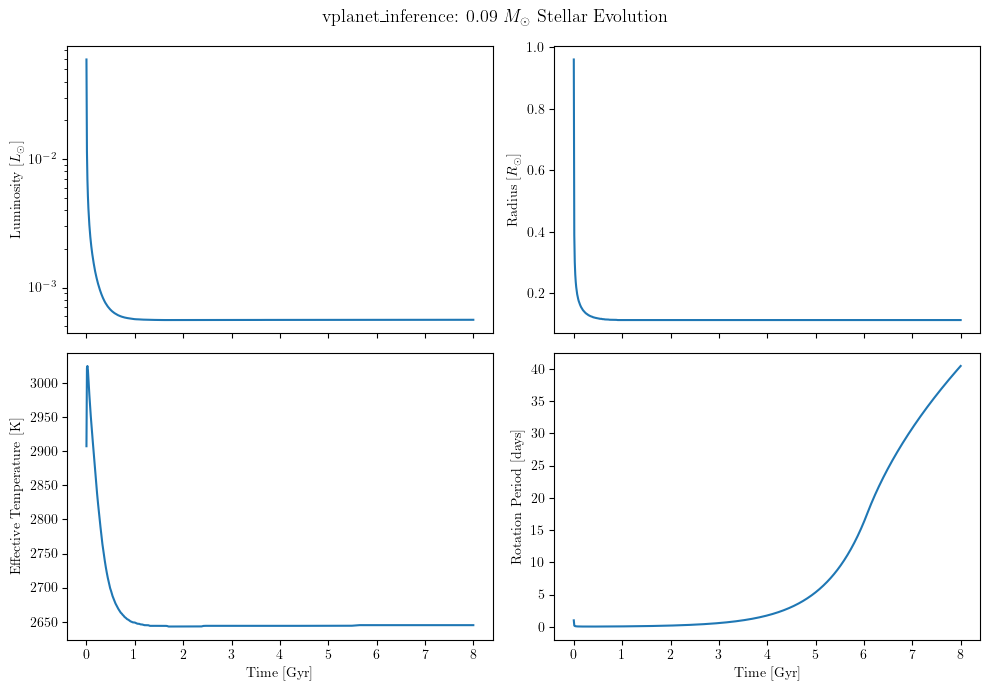

In [21]:
time_gyr = evol["Time"].to(u.Gyr).value

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

axes[0, 0].semilogy(time_gyr, evol["final.star.Luminosity"].value)
axes[0, 0].set_ylabel(r"Luminosity [$L_\odot$]")

axes[0, 1].plot(time_gyr, evol["final.star.Radius"].value)
axes[0, 1].set_ylabel(r"Radius [$R_\odot$]")

axes[1, 0].plot(time_gyr, evol["final.star.Temperature"].value)
axes[1, 0].set_ylabel("Effective Temperature [K]")

axes[1, 1].plot(time_gyr, evol["final.star.RotPer"].value)
axes[1, 1].set_ylabel("Rotation Period [days]")

for ax in axes[1]:
    ax.set_xlabel("Time [Gyr]")

fig.suptitle(
    r"vplanet\_inference: 0.09 $M_\odot$ Stellar Evolution",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Summary

| Task | How |
|------|-----|
| Set up input files | Edit `vpl.in` (system settings) and `<body>.in` (body parameters + `saModules`) |
| Run from command line | `cd <infile_dir>` → `vplanet vpl.in` |
| Read log file | Open `<SystemName>.log` for initial/final values of all quantities (SI units) |
| Read forward file | `np.loadtxt("<SystemName>.<body>.forward")` — columns match `saOutputOrder` |
| Run from Python | `VplanetModel(inparams, outparams, inpath=...)` → `run_model(theta)` |
| Specify input units | Values in `inparams` dict use `astropy.units`; converted to SI automatically |
| Specify output units | Values in `outparams` dict use `astropy.units`; results returned in those units |
| Vary parameters | Change entries in `theta`; no need to edit any files |
| Track time evolution | Pass `timesteps=<Quantity>` to `VplanetModel`; `run_model()` returns a dict of arrays |

**Next steps:**
- Explore other VPLanet modules (tidal evolution, atmospheric escape, orbital dynamics)
  in the [VPLanet module documentation](https://virtualplanetarylaboratory.github.io/vplanet/modules.html)
- Run parameter sweeps and Bayesian inference using `vplanet_inference.AnalyzeVplanetModel`
  (see the **Quickstart** section of the documentation)